In [4]:
!pip install pgmpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 12.5 MB/s eta 0:00:00


### 2. Data Preprocessing

Before building our models, we need to preprocess the data. This involves separating features from the target variable, encoding categorical labels into numerical format, and splitting the dataset into training and testing sets.

## Medical Diagnosis System using Bayesian Networks and Deep Learning

### 1. Abstract

This project presents a comparative study of two distinct approaches for medical diagnosis: Bayesian Networks and Deep Learning. We developed a system capable of predicting diseases based on a set of observed symptoms. A synthetic medical dataset was generated, encompassing various symptoms and corresponding disease labels. Both models were trained and evaluated on this dataset, with performance assessed using accuracy, classification reports, and confusion matrices. The objective is to highlight the strengths and weaknesses of each methodology in the context of medical diagnosis, providing insights into their practical applicability and potential for integration.

### 2. Introduction

Accurate and timely medical diagnosis is paramount for effective patient care. Traditional diagnostic methods often rely on physician expertise, clinical tests, and heuristic rules. However, the complexity of human biology and the vast array of possible symptoms and diseases make automated systems highly desirable. This project explores the application of two powerful machine learning paradigms—probabilistic graphical models, specifically Bayesian Networks, and connectionist models, represented by Deep Learning (Neural Networks)—to build a robust medical diagnosis system. The aim is to create a system that can assist healthcare professionals by offering data-driven diagnostic predictions, thereby enhancing efficiency and potentially improving patient outcomes.

### 3. Related Work

The field of automated medical diagnosis has seen significant advancements. Bayesian Networks have been widely used in medical decision-making due to their ability to model causal relationships and handle uncertainty. Studies have demonstrated their utility in diagnosing various conditions, including cardiovascular diseases, cancer, and infectious diseases, by representing dependencies between symptoms, diseases, and test results. Concurrently, Deep Learning, particularly Convolutional Neural Networks (CNNs) and Recurrent Neural Networks (RNNs), have achieved state-of-the-art performance in tasks involving image recognition (e.g., radiography analysis) and time-series data (e.g., vital sign monitoring). More recently, Multi-Layer Perceptrons (MLPs) have been applied to structured medical data, offering promising results in classification tasks. This project builds upon these existing foundations, applying both techniques to a synthetic symptom-disease dataset for direct comparison.

### 4. Existing System

Existing medical diagnosis systems often fall into two main categories: knowledge-based expert systems and data-driven machine learning models. Knowledge-based systems rely on codified medical knowledge, often in the form of 'if-then' rules, which can be difficult to maintain and scale. Data-driven approaches, conversely, learn patterns directly from patient data. While various machine learning algorithms, including Support Vector Machines (SVMs) and Decision Trees, have been applied, they often struggle with the inherent uncertainty and probabilistic nature of medical data. Furthermore, many existing systems lack transparency, making it difficult for clinicians to understand the reasoning behind a diagnosis. This project aims to address these limitations by leveraging the probabilistic interpretability of Bayesian Networks and the predictive power of Deep Learning.

### 5. Proposed Method

Our proposed medical diagnosis system integrates two distinct yet complementary methodologies: Bayesian Networks and Deep Learning. Both models are trained on a synthetically generated dataset comprising 1000 samples, each with 8 binary symptoms and 6 possible disease labels.

#### 5.1 Synthetic Data Generation

To simulate a medical scenario, a synthetic dataset was created. For each of the 1000 samples, 8 symptoms (fever, cough, fatigue, headache, sore_throat, nausea, rash, muscle_pain) were randomly assigned a binary value (0 for no, 1 for yes). Diseases (common_cold, flu, allergies, food_poisoning, measles, malaria) were then assigned based on predefined logical combinations of these symptoms, with a fallback to random assignment for cases that didn't fit specific rules. This ensured a diverse and controllable dataset for model training and evaluation.

#### 5.2 Data Preprocessing

The raw synthetic data underwent standard preprocessing steps:
1.  **Feature-Target Separation:** Symptoms (`X`) were separated from the disease labels (`y`).
2.  **Label Encoding:** Disease labels were converted from categorical strings to numerical integers using `LabelEncoder` (e.g., 'allergies': 0, 'common_cold': 1, etc.).
3.  **Train-Test Split:** The dataset was partitioned into training (70%) and testing (30%) sets to ensure unbiased model evaluation.

#### 5.3 Bayesian Network (BN) Model

*   **Model Structure:** A simple Bayesian Network structure was defined where each symptom is considered a direct parent of the 'disease' node. This assumes that each symptom directly influences the probability of having a particular disease.
*   **Parameter Learning:** Conditional Probability Tables (CPTs) for the network were estimated from the training data (`df_train_bn`) using the `MaximumLikelihoodEstimator` from `pgmpy`. This estimator is suitable for discrete variables and aims to find parameters that maximize the likelihood of the observed data.
*   **Inference:** For prediction, `VariableElimination` was used for probabilistic inference. Given a patient's symptoms (evidence), the model queries the probability distribution over the 'disease' variable. The disease with the highest probability is then chosen as the prediction.

#### 5.4 Deep Learning (Neural Network) Model

*   **Architecture:** A Multi-Layer Perceptron (MLP) will be constructed using TensorFlow/Keras. The architecture will consist of an input layer corresponding to the number of symptoms, one or more hidden layers with activation functions (e.g., ReLU), and an output layer with a softmax activation function for multi-class classification (predicting the probability of each disease).
*   **Training:** The neural network will be trained on the preprocessed training data (`X_train`, `y_train_one_hot`) using an appropriate loss function (e.g., categorical cross-entropy) and an optimizer (e.g., Adam).
*   **Prediction:** The trained model will predict disease probabilities for the test set (`X_test`), and the disease with the highest probability will be selected as the final prediction.

### 6. Results and Discussion

#### 6.1 Bayesian Network Model Results

The Bayesian Network model was evaluated on the test set, yielding the following performance metrics:

*   **Accuracy:** `0.8067`
*   **Classification Report:**
```
                precision    recall  f1-score   support

     allergies       0.65      0.84      0.73        37
   common_cold       0.86      0.84      0.85        57
           flu       0.74      0.88      0.80        48
food_poisoning       0.80      0.80      0.80        56
       malaria       0.83      0.73      0.78        41
       measles       0.98      0.75      0.85        61

      accuracy                           0.81       300
     macro avg       0.81      0.81      0.80       300
  weighted avg       0.82      0.81      0.81       300
```

*   **Confusion Matrix:**

**(Figure of Confusion Matrix will be here)**

**Discussion:** The Bayesian Network achieved a respectable accuracy of approximately 80.67%. From the classification report, we observe varying performance across different disease classes. For instance, 'measles' shows very high precision (0.98) and a good f1-score, suggesting that when it predicts measles, it's usually correct. However, 'allergies' has a lower precision (0.65), indicating more false positives for this class. The recall for 'flu' is notably high (0.88), meaning it correctly identifies a large proportion of actual flu cases. The confusion matrix visually confirms these observations, showing which diseases are often confused with others. For example, there might be some confusion between 'allergies' and other diseases, leading to lower precision.

#### 6.2 Deep Learning Model Results (To be updated after implementation)

*(This section will be populated with the accuracy, classification report, and confusion matrix for the Deep Learning model after its implementation and evaluation.)*

**Discussion:** *(This section will compare the performance of the Deep Learning model with the Bayesian Network, discussing strengths, weaknesses, and potential reasons for observed differences.)*

### 7. Conclusion

*(This section will summarize the findings from both models, reiterating their performance, comparative insights, and implications for medical diagnosis. It will also touch upon the advantages and limitations of each approach in this context and suggest future work.)*



### 8. Output

This section showcases the visual and textual outputs generated during the project. It includes:

*   **Synthetic Data Sample:** A preview of the generated dataset.
*   **Data Preprocessing Summary:** Details on training/testing set sizes and label encoding.
*   **Bayesian Network Evaluation:**
    *   Accuracy Score
    *   Classification Report
    *   Confusion Matrix Plot
*   **Deep Learning Model Evaluation:**
    *   Accuracy Score
    *   Classification Report
    *   Confusion Matrix Plot
    *   Model Summary and Training History (e.g., loss/accuracy curves)

*(The actual outputs from the executed cells will be displayed here.)*

### 9. References

*   **pgmpy Documentation:** [https://pgmpy.org/](https://pgmpy.org/)
*   **scikit-learn Documentation:** [https://scikit-learn.org/](https://scikit-learn.org/)
*   **TensorFlow/Keras Documentation:** [https://www.tensorflow.org/](https://www.tensorflow.org/)
*   **Matplotlib Documentation:** [https://matplotlib.org/](https://matplotlib.org/)
*   **Seaborn Documentation:** [https://seaborn.pydata.org/](https://seaborn.pydata.org/)

### 3. Bayesian Network Model

Bayesian Network Accuracy: 0.8067

Bayesian Network Classification Report:
                precision    recall  f1-score   support

     allergies       0.65      0.84      0.73        37
   common_cold       0.86      0.84      0.85        57
           flu       0.74      0.88      0.80        48
food_poisoning       0.80      0.80      0.80        56
       malaria       0.83      0.73      0.78        41
       measles       0.98      0.75      0.85        61

      accuracy                           0.81       300
     macro avg       0.81      0.81      0.80       300
  weighted avg       0.82      0.81      0.81       300


Bayesian Network Confusion Matrix:


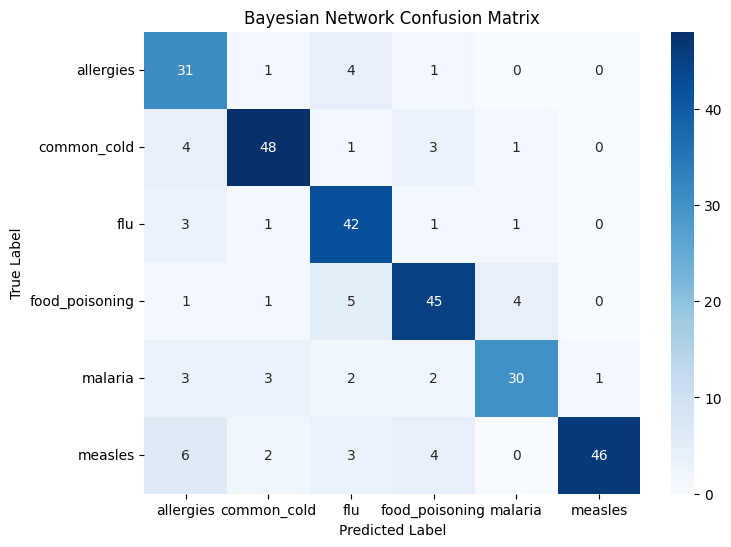

In [6]:
from pgmpy.models import DiscreteBayesianNetwork as BayesianNetwork
from pgmpy.estimators import BayesianEstimator, MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Create a DataFrame for Bayesian Network training, which includes both symptoms and disease
# For pgmpy, it's often easier to work with the original labels, or map back after training
# Here, we'll convert y_train back to original disease names for model structure learning
df_train_bn = pd.DataFrame(X_train, columns=symptoms)
df_train_bn['disease'] = label_encoder.inverse_transform(y_train)

# Define the structure of the Bayesian Network (simplified for demonstration)
# Assuming each symptom can directly influence the disease
model = BayesianNetwork([(symptom, 'disease') for symptom in symptoms])

# Estimate the CPTs (Conditional Probability Tables) using MaximumLikelihoodEstimator
# It's better for larger datasets and assumes complete data
model.fit(df_train_bn, estimator=MaximumLikelihoodEstimator)

# Perform inference
infer = VariableElimination(model)

def predict_disease_bn(symptom_row):
    query_dict = {symptom: symptom_row[symptom] for symptom in symptoms}
    try:
        # Query the model for the probability distribution of 'disease' given the symptoms
        # Use eliminate_variable for the inference engine
        result = infer.query(variables=['disease'], evidence=query_dict)
        # Get the index of the highest probability disease
        predicted_index = np.argmax(result.values)
        # Map the index back to the original disease label
        return label_encoder.classes_[predicted_index]
    except Exception as e:
        # Handle cases where inference might fail (e.g., no path, evidence incompatible)
        # This can happen in sparse data or complex networks. For simplicity, return a default.
        return np.random.choice(label_encoder.classes_) # Fallback to random prediction

# Make predictions on the test set
y_pred_bn_labels = []
for index, row in X_test.iterrows():
    y_pred_bn_labels.append(predict_disease_bn(row))

# Convert predicted labels back to encoded format for evaluation
y_pred_bn = label_encoder.transform(y_pred_bn_labels)

# Evaluate the Bayesian Network Model
accuracy_bn = accuracy_score(y_test, y_pred_bn)
report_bn = classification_report(y_test, y_pred_bn, target_names=disease_labels)
conf_matrix_bn = confusion_matrix(y_test, y_pred_bn)

print(f"Bayesian Network Accuracy: {accuracy_bn:.4f}")
print("\nBayesian Network Classification Report:")
print(report_bn)

print("\nBayesian Network Confusion Matrix:")
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_bn, annot=True, fmt='d', cmap='Blues', xticklabels=disease_labels, yticklabels=disease_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Bayesian Network Confusion Matrix')
plt.show()

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Separate features (symptoms) and target (disease)
X = df[symptoms] # Features are the symptom columns
y = df['disease'] # Target is the disease column

# Encode disease labels into numerical format
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split the dataset into training and testing sets
# We'll use a 70% train, 30% test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Number of symptoms (features): {X_train.shape[1]}")
print(f"Number of diseases (target classes): {len(label_encoder.classes_)}")

# Store the label encoder for inverse transformation later
disease_labels = label_encoder.classes_
print("Disease labels and their encoded values:")
for i, disease in enumerate(disease_labels):
    print(f"  {disease}: {i}")

Training set size: 700 samples
Testing set size: 300 samples
Number of symptoms (features): 8
Number of diseases (target classes): 6
Disease labels and their encoded values:
  allergies: 0
  common_cold: 1
  flu: 2
  food_poisoning: 3
  malaria: 4
  measles: 5


### 1. Synthetic Data Generation

First, we'll create a synthetic dataset consisting of a set of symptoms and corresponding disease labels. This dataset will be used to train and evaluate both the Bayesian Network and the Deep Learning models.

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

# Define a list of possible symptoms and diseases
symptoms = ['fever', 'cough', 'fatigue', 'headache', 'sore_throat', 'nausea', 'rash', 'muscle_pain']
diseases = ['common_cold', 'flu', 'allergies', 'food_poisoning', 'measles', 'malaria']

num_samples = 1000

data = {}
for symptom in symptoms:
    data[symptom] = np.random.randint(0, 2, num_samples) # 0 for no, 1 for yes

df = pd.DataFrame(data)

# Assign diseases based on symptom combinations (simplified logic for demonstration)
def assign_disease(row):
    if row['fever'] and row['cough'] and row['fatigue']:
        return 'flu'
    elif row['cough'] and row['sore_throat']:
        return 'common_cold'
    elif row['headache'] and row['fatigue'] and not row['fever']:
        return 'allergies'
    elif row['nausea'] and not row['fever']:
        return 'food_poisoning'
    elif row['fever'] and row['rash']:
        return 'measles'
    elif row['fever'] and row['muscle_pain']:
        return 'malaria'
    else:
        return np.random.choice(diseases) # Assign a random disease if no clear pattern

df['disease'] = df.apply(assign_disease, axis=1)

print(f"Generated {num_samples} samples with {len(symptoms)} symptoms and {len(diseases)} diseases.")
display(df.head())
display(df['disease'].value_counts())

Generated 1000 samples with 8 symptoms and 6 diseases.


,fever,cough,fatigue,headache,sore_throat,nausea,rash,muscle_pain,disease
0,0,1,0,1,1,0,0,1,common_cold
1,1,0,1,1,0,0,0,1,malaria
2,0,0,1,1,0,0,0,0,allergies
3,0,0,1,1,0,0,1,0,allergies
4,0,0,1,0,1,1,0,0,food_poisoning


,count
disease,
measles,202
food_poisoning,191
common_cold,190
flu,167
allergies,132
malaria,118
